<a href="https://colab.research.google.com/github/UghurKhalilov/Instacart-market-basket-analysis/blob/main/Instacart_Market_Basket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instacart Market Basket Analysis
## Exploratory Data Analysis with Python & Pandas

This project analyzes the Instacart grocery shopping dataset containing
over 3 million orders from 200,000+ customers. The goal is to uncover
customer purchasing behavior, product popularity, and reorder patterns
through structured data cleaning and exploratory analysis.

**Dataset:** 5 tables — orders, products, departments, aisles, order_products  
**Tools:** Python, Pandas, Matplotlib, NumPy

In [1]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
orders         = pd.read_csv('/content/drive/MyDrive/dataset/instacart_orders.csv', sep=';')
products       = pd.read_csv('/content/drive/MyDrive/dataset/products.csv', sep=';')
departments    = pd.read_csv('/content/drive/MyDrive/dataset/departments.csv', sep=';')
aisles         = pd.read_csv('/content/drive/MyDrive/dataset/aisles.csv', sep=';')
order_products = pd.read_csv('/content/drive/MyDrive/dataset/order_products.csv', sep=';')

## Step 1: Data Cleaning — Duplicate Detection & Removal

Each of the five tables was systematically checked for duplicate records.
15 duplicate rows were identified and removed from the orders table,
all originating from Wednesday at 2:00 AM — likely a data pipeline issue.
The remaining tables (products, departments, aisles, order_products)
contained no fully duplicate rows. Product names were standardized to
lowercase to ensure consistent comparison.

### `orders` data frame

In [ ]:
# Check for duplicated orders
orders.duplicated().sum()

np.int64(15)

In [ ]:
# Check for all orders placed Wednesday at 2:00 AM
orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)].duplicated().sum()

np.int64(15)

In [ ]:
# Remove duplicate orders
orders.drop_duplicates(inplace=True)

In [ ]:
# Double check for duplicate rows
orders.duplicated().sum()

np.int64(0)

In [ ]:
# Double check for duplicate order IDs only
orders['order_id'].duplicated().sum()

np.int64(0)

### `products` data frame

In [ ]:
# Check for fully duplicate rows
products.duplicated().sum()

np.int64(0)

In [ ]:
# Check for just duplicate product IDs
products['product_id'].duplicated().sum()

np.int64(0)

In [ ]:
# Check for just duplicate product names (convert names to lowercase to compare better)
products['product_name']=products['product_name'].str.lower()
products['product_name'].duplicated().sum()

np.int64(1361)

In [ ]:
# Check for duplicate product names that aren't missing
products['product_name'].notna().duplicated().sum()

np.int64(49692)

### `departments` data frame

In [ ]:
# Check for fully duplicate rows
departments.duplicated().sum()

np.int64(0)

### `aisles` data frame

In [ ]:
# Check for fully duplicate rows
aisles.duplicated().sum()

np.int64(0)

### `order_products` data frame

In [ ]:
# Check for fullly duplicate rows
order_products.duplicated().sum()

np.int64(0)

In [ ]:
# Check if product_id has duplicate entries (same product in multiple orders is expected)
order_products['product_id'].duplicated().sum()

np.int64(4499434)

## Step 2: Data Cleaning — Missing Value Treatment

Two sources of missing data were identified and addressed:

- **orders table:** 28,817 missing values in `days_since_prior_order`.
  These correspond to each customer's very first order, where no prior
  order exists by definition. These were retained as-is since they are
  structurally expected, not errors.

- **products table:** Missing product names were filled with 'Unknown'
  to preserve referential integrity across tables.
  

- **order_products table:** 836 missing values in `add_to_cart_order`.
  These records were kept in the dataset as they do not affect
  the core analyses.



### `orders` data frame

In [ ]:
# Are there any missing values where it's not a customer's first order?
orders[orders['order_id']>1].isnull().sum()

,0
order_id,0
user_id,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,28817


In [ ]:
# Check for missing values in all columns
orders.isnull().sum()

,0
order_id,0
user_id,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,28817


### `products` data frame

In [ ]:
# Check for missing values in all columns
products.isnull().sum()

,0
product_id,0
product_name,1258
aisle_id,0
department_id,0


In [ ]:
# Are all of the missing product names associated with aisle ID 100?
(products[products['product_name'].isnull()]['aisle_id'] == 100).all()

np.True_

In [ ]:
# Are all of the missing product names associated with department ID 21?
(products[products['product_name'].isnull()]['department_id']==21).all()

np.True_

In [ ]:
# Identify which aisle and department the missing product names belong to
# aisle_id 100 and department_id 21 correspond to items without a proper category

In [ ]:
# Fill missing product names with 'Unknown'
products['product_name'].fillna('Unknown',inplace=True)

/tmp/ipykernel_3234/309396220.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_name'].fillna('Unknown',inplace=True)


### `order_products` data frame

In [ ]:
# Check for missing values in all columns
order_products.isnull().sum()

,0
order_id,0
product_id,0
add_to_cart_order,836
reordered,0


In [ ]:
# What are the min and max values in this column?
order_products.agg({
    'order_id': ['min', 'max'],
    'product_id': ['min', 'max'],
    'add_to_cart_order': ['min', 'max'],
    'reordered': ['min', 'max']
})

,order_id,product_id,add_to_cart_order,reordered
min,4,1,1.0,0
max,3421079,49694,64.0,1


In [ ]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()

array([2449164, 1968313, 2926893, 1717990, 1959075,  844733,   61355,
        936852,  264710, 1564093,  129627,  293169, 2849370, 1386261,
       3308010,  903110, 2136777, 3347453, 1888628,  165801, 2094761,
       1038146, 2997021,  813364, 2256933,  171934, 2409109, 1730767,
       1169835,  733526,  404157, 3125735,  747668, 1800005, 1961723,
        871281,  388234, 1648217, 1477139,  102236, 1021563, 1832957,
       2721963,  678116, 1220886, 1673227, 2999801, 1633337, 2470674,
       2625444, 1677118, 2479011, 3383594, 1183255, 1713430, 2652650,
       1598369, 1916118,  854647, 1302315,  888470,  180546, 2621907,
       1308785, 2729254,    9310, 2170451, 2979697, 1625713, 1529171])

In [ ]:
# Do all orders with missing values have more than 64 products?
missing_orders = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
product_counts = order_products.groupby('order_id').size()
(product_counts.loc[missing_orders] > 64).all()

np.True_

In [ ]:
# Replace missing values with 999 and convert column to integer type
order_products['add_to_cart_order']=order_products['add_to_cart_order'].fillna(999).astype(int)

# Exploratory Data Analysis

### Data Validation — Order Hour and Day of Week

Verified that all values in `order_hour_of_day` fall within the
expected range of 0–23, and `order_dow` within 0–6.
Both columns passed validation with no out-of-range values detected.

In [ ]:
# Verify order_hour_of_day is within 0-23 and order_dow is within 0-6
orders[['order_hour_of_day','order_dow']].agg(['min','max'])

,order_hour_of_day,order_dow
min,0,0
max,23,6


### Customer Order Frequency

Analyzed how many times each customer has placed an order.
The distribution reveals that most customers are repeat buyers,
with the majority having placed between 3–15 orders.
A small but notable segment of highly loyal customers
has placed over 50 orders on the platform.

In [ ]:
# Count orders by hour of day to identify peak shopping hours
orders['order_hour_of_day'].value_counts().sort_index()

,count
order_hour_of_day,
0,3180
1,1763
2,989
3,770
4,765
5,1371
6,4215
7,13043
8,25024


### What Day of the Week Do People Shop?

Days 0 and 1 (Sunday and Monday) account for the highest order volumes,
with over 84,000 and 82,000 orders respectively. Order frequency
declines steadily through the middle of the week, suggesting customers
prefer to stock up at the start of the week.

In [ ]:
# Count orders by day of week (0=Sunday, 6=Saturday)
orders['order_dow'].value_counts().sort_index()

,count
order_dow,
0,84090
1,82185
2,65833
3,60897
4,59810
5,63488
6,62649


### Days Between Orders

Examined how many days customers typically wait before placing
their next order. The most common interval is 7 days, suggesting
a weekly shopping habit. A significant spike at 30 days indicates
a monthly shopping pattern among another customer segment.
The 28,817 missing values represent each customer's very first
order, where no prior order exists.

In [ ]:
# Count how many days customers wait between orders to identify shopping frequency patterns
orders['days_since_prior_order'].value_counts().sort_index()

,count
days_since_prior_order,
0.0,9589
1.0,20179
2.0,27138
3.0,30224
4.0,31006
5.0,30096
6.0,33930
7.0,44577
8.0,25361


# Customer & Order Behavior Analysis

## Wednesday vs Saturday: Order Hour Distribution

The histogram reveals clear differences in ordering behavior between the two days:

- **Saturday:** Orders are spread throughout the entire day.
  There is noticeable activity in late-night hours (0–2), suggesting
  people order after going out. Evening orders (15–20) remain high,
  indicating Saturday is an all-day shopping day.

- **Wednesday:** Orders are concentrated around midday (10–15).
  Late-night and evening activity drops significantly, which is
  typical for a weekday when people follow work schedules.

**Conclusion:** Saturday shows a "night market" effect with orders
continuing late into the evening and night, while Wednesday follows
a standard workday pattern with a sharp midday peak.

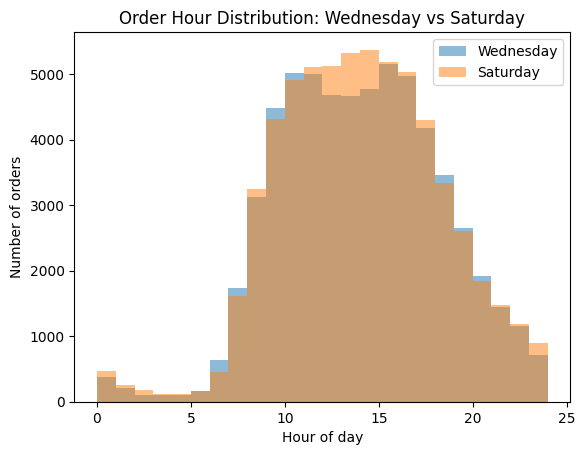

In [ ]:
# Filter Wednesday (dow=3) and Saturday (dow=6), plot overlapping histograms
import matplotlib.pyplot as plt
wdays=orders[orders['order_dow']==3]
sdays=orders[orders['order_dow']==6]

plt.hist(wdays['order_hour_of_day'], bins=24, range=(0,24), alpha=0.5, label='Wednesday')
plt.hist(sdays['order_hour_of_day'], bins=24, range=(0,24), alpha=0.5, label='Saturday')
plt.title('Order Hour Distribution: Wednesday vs Saturday')
plt.xlabel('Hour of day')
plt.ylabel('Number of orders')
plt.legend()
plt.show()

### Number of Orders per Customer

Analyzed how many orders each customer has placed. Most customers
are repeat buyers, with the majority placing between 3–15 orders.
A small but notable segment of highly loyal customers has placed
over 50 orders on the platform.

In [ ]:
# Count total orders per customer
orders['user_id'].value_counts().reset_index()

,user_id,count
0,149605,28
1,193164,26
2,78375,25
3,134511,24
4,148162,24
...,...,...
157432,73221,1
157433,112002,1
157434,82546,1
157435,60017,1


### Top 20 Most Popular Products

Identified the 20 most frequently purchased products overall.
Fresh produce dominates the list, with bananas and organic
strawberries ranking among the top items, confirming that
everyday staples drive the majority of orders.

In [ ]:
# Display top 20 most purchased products by product_id and product_name
products[['product_id','product_name']].value_counts().head(20)

,,count
product_id,product_name,
49694,burrito- steak & cheese,1
1,chocolate sandwich cookies,1
2,all-seasons salt,1
3,robust golden unsweetened oolong tea,1
4,smart ones classic favorites mini rigatoni with vodka cream sauce,1
5,green chile anytime sauce,1
6,dry nose oil,1
7,pure coconut water with orange,1
8,cut russet potatoes steam n' mash,1


# Product & Reorder Analysis

### Items per Order Distribution

Most customers purchase between 5–10 items per order. The distribution
is right-skewed, with a small number of orders containing significantly
more items, indicating occasional large bulk purchases.

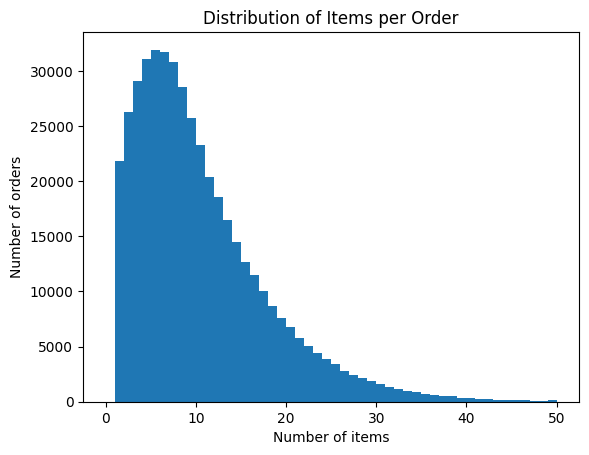

In [ ]:
# Count items per order, plot distribution as histogram
costumers_items=order_products.groupby('order_id')['product_id'].agg('count')
plt.hist(costumers_items, bins=50, range=(0, 50))
plt.xlabel('Number of items')
plt.ylabel('Number of orders')
plt.title('Distribution of Items per Order')
plt.show()


### Top 20 Most Reordered Products

Fresh produce dominates the reorder list, with bananas, organic
strawberries, and baby spinach ranking highest. This confirms that
everyday staples drive repeat purchasing behavior on the platform.

In [ ]:
# Filter reordered items, count by product, sort and take top 20, merge with product names
reordered_item=order_products[order_products['reordered']==1]

top_20_items=reordered_item.groupby('product_id')['reordered'].agg('count').sort_values(ascending=False).reset_index().head(20)
new_frame=top_20_items.merge(products,on='product_id')
new_frame[['product_name','product_id','reordered']]

,product_name,product_id,reordered
0,banana,24852,55763
1,bag of organic bananas,13176,44450
2,organic strawberries,21137,28639
3,organic baby spinach,21903,26233
4,organic hass avocado,47209,23629
5,organic avocado,47766,18743
6,organic whole milk,27845,16251
7,large lemon,47626,15044
8,organic raspberries,27966,14748
9,strawberries,16797,13945


### Reorder Rate by Product

Everyday essentials such as dairy, eggs, and fresh produce show the
highest reorder rates, indicating habitual purchasing. Niche or
seasonal products tend to have lower reorder rates, suggesting they
are tried rather than routinely purchased.

In [ ]:
# Calculate mean reorder rate per product, merge with product names

reorder_proportion = order_products.groupby('product_id')['reordered'].agg('mean').reset_index()
product_reorder_proportion = reorder_proportion.merge(products,on='product_id')
product_reorder_proportion

,product_id,reordered,product_name,aisle_id,department_id
0,1,0.564286,chocolate sandwich cookies,61,19
1,2,0.000000,all-seasons salt,104,13
2,3,0.738095,robust golden unsweetened oolong tea,94,7
3,4,0.510204,smart ones classic favorites mini rigatoni wit...,38,1
4,7,0.500000,pure coconut water with orange,98,7
...,...,...,...,...,...
45568,49690,0.800000,high performance energy drink,64,7
45569,49691,0.430556,original pancake & waffle mix,130,14
45570,49692,0.416667,organic instant oatmeal light maple brown sugar,130,14
45571,49693,0.440000,spring water body wash,127,11


### Reorder Rate by Customer

The majority of customers show a high reorder rate, indicating strong
product loyalty. A smaller segment consistently explores new products,
reflecting a more discovery-oriented shopping style.

In [ ]:
# Merge order_products with orders to get user_id, then calculate mean reorder rate per customer
reordered_for_costumers=order_products.merge(orders,on='order_id')
reorder_products=reordered_for_costumers.groupby('user_id')['reordered'].agg('mean').reset_index()
reorder_products

,user_id,reordered
0,2,0.038462
1,4,0.000000
2,5,0.666667
3,6,0.000000
4,7,0.928571
...,...,...
149621,206203,0.222222
149622,206206,0.714286
149623,206207,0.891304
149624,206208,0.696000


### Top 20 Items Added to Cart First

Fresh produce overwhelmingly dominates — Bananas rank #1 with over
15,000 instances — suggesting that customers begin their shopping
with planned, high-frequency staples rather than impulse purchases.

In [ ]:
# Filter products added first to cart, count by product, merge with names
first_order=order_products[order_products['add_to_cart_order']==1]
first_order.groupby('product_id')['order_id'].agg('count').sort_values(ascending=False).head(20)


,order_id
product_id,
24852,15562
13176,11026
27845,4363
21137,3946
47209,3390
21903,3336
47766,3044
19660,2336
16797,2308
